# EM casing response dipole source

In [1]:
import numpy as np
import os
import scipy.sparse as sp
import pandas as pd
from scipy.constants import mu_0
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LinearSegmentedColormap, Normalize, SymLogNorm
from matplotlib import cm as colormap
import time
from string import ascii_lowercase
import pickle
from multiprocessing import Pool

# SimPEG, discretize/
import discretize
from discretize import utils
from simpeg.electromagnetics import frequency_domain as fdem
from simpeg.electromagnetics.static import resistivity as dc
from simpeg.electromagnetics.utils import line_through_faces
from simpeg import(
    maps, Report, data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
    utils
)
from pymatsolver import Pardiso

from utils import pad_for_casing_and_data

In [2]:
from matplotlib import rcParams
rcParams["font.size"] = 16

In [3]:
directory_path = "/t40array/lheagy/casing-upscaling"

In [4]:
def ensure_directory_exists(directory_path):
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)
        print(f"Directory '{directory_path}' created.")
    else:
        print(f"Directory '{directory_path}' already exists.")

# Example usage
ensure_directory_exists(directory_path)

Directory '/t40array/lheagy/casing-upscaling' already exists.


In [5]:
save_figures = False
fig_dir_high = "figures"
fig_dir_low = "low-rez-figures"

dpi_high=400
dpi_low=150

## Simulation parameters

In [175]:
# # conductivities
sigma_air = 1e-1
sigma_back = np.r_[1e-1]
casing_l = 500
sigma_casing = 1e-1 #5e6
mur_casing = np.r_[1, 2, 10, 25, 50, 100, 150, 200]

# # casing geometry
casing_b = 5e-2  
casing_t = 5e-2 #1e-2 #np.r_[5e-3, 7.5e-3, 10e-3, 12.5e-3, 15e-3, 20e-3]
casing_a = casing_b - casing_t

In [176]:
src_dz = 10
src_z = -250 #np.r_[-100, -250, -400, -495, -500, -550, -600]

In [177]:
# generate a mesh
hx = pad_for_casing_and_data(
   casing_outer_radius = casing_b,
    csx1 = casing_t/8, 
    csx2 = 25, 
    pfx1 = 1.3,
    pfx2 = 1.5, 
    domain_x = 600, 
    npadx = 10
)

pfz = 1.3
npad_z = 28
csz = 0.5
n_core_extra = 10
ncore_z = int(np.max(np.r_[np.abs(casing_l), np.abs(src_z)]) / csz) + n_core_extra
hz = discretize.utils.unpack_widths(
    [(csz, npad_z, -pfz), (csz, ncore_z), (csz, npad_z, pfz)]
)

<Axes: xlabel='x', ylabel='z'>

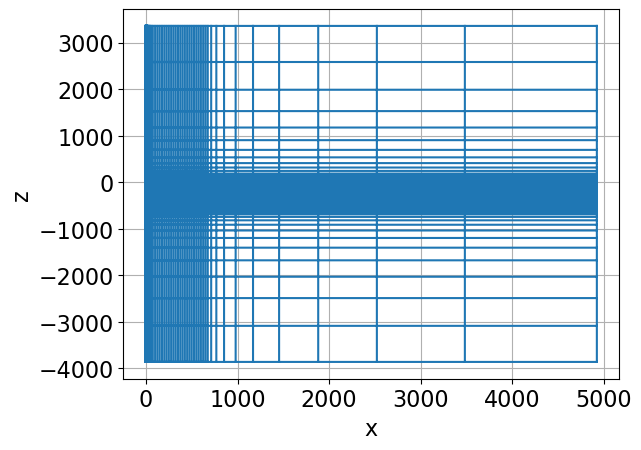

In [178]:
mesh = discretize.CylindricalMesh(
    [hx, np.r_[2*np.pi], hz], origin=np.r_[0, 0, -np.sum(hz[:npad_z + int(ncore_z)])],
)

fig, ax = plt.subplots(1, 1)
mesh.plot_grid(ax=ax)
# ax.set_xlim([0, 5])
# ax.set_ylim(-50, 10)

In [179]:
mesh.n_cells

79950

In [180]:
def get_physical_property_model(mesh, casing_a, casing_b, casing_l, sigma_back, sigma_casing, sigma_air=sigma_air, mur_casing=1):

    model = np.ones(mesh.n_cells)*sigma_air
    model[mesh.cell_centers[:, 2] < 0] = sigma_back

    mur = np.ones(mesh.n_cells)

    inds_casing_x = (
        (mesh.cell_centers[:, 0] > casing_a) & 
        (mesh.cell_centers[:, 0] < casing_b)
    )
    inds_casing_z = (
        (mesh.cell_centers[:, 2] < 0) &
        (mesh.cell_centers[:, 2] > -casing_l)
    )
    inds_casing = inds_casing_x & inds_casing_z

    model[inds_casing] = sigma_casing
    mur[inds_casing] = mur_casing

    return model, mur

    

In [181]:
sigma_back

array([0.1])

In [182]:
models = {}
for mur in mur_casing:
    key = f"casing_sig{sigma_casing:1.0e}_mur{mur:1.0f}"
    sig_model, mur_model = get_physical_property_model(mesh, casing_a, casing_b, casing_l, sigma_back[0], sigma_casing, mur_casing=mur)
    models[key] = {
        "sigma": sig_model, 
        "mur": mur_model
    }
keys = list(models.keys())

In [183]:
keys

['casing_sig1e-01_mur1',
 'casing_sig1e-01_mur2',
 'casing_sig1e-01_mur10',
 'casing_sig1e-01_mur25',
 'casing_sig1e-01_mur50',
 'casing_sig1e-01_mur100',
 'casing_sig1e-01_mur150',
 'casing_sig1e-01_mur200']

In [184]:
def plot_casing(model, xlim=None, zlim=None, vmin=None, vmax=None, ax=None, cb_label=None, logscale=True, show_cb=False): 
    if ax is None: 
        fig, ax = plt.subplots(1, 1)
    if logscale is True: 
        pcolor_opts={"norm":LogNorm(vmin=vmin, vmax=vmax), "cmap":"Spectral_r"}
    else: 
        pcolor_opts={"norm":Normalize(vmin=vmin, vmax=vmax), "cmap":"Spectral_r"}
    out = mesh.plot_image(
        model, pcolor_opts=pcolor_opts, ax=ax, mirror=True
    )

    if show_cb is True: 
        cb = plt.colorbar(out[-1], shrink=0.5)
        cb.set_label(cb_label)

    if xlim is not None: 
        ax.set_xlim(xlim)
    if zlim is not None: 
        ax.set_ylim(zlim)

    ax.set_xlabel("x (m)")
    ax.set_ylabel("z (m)")
    return ax, out

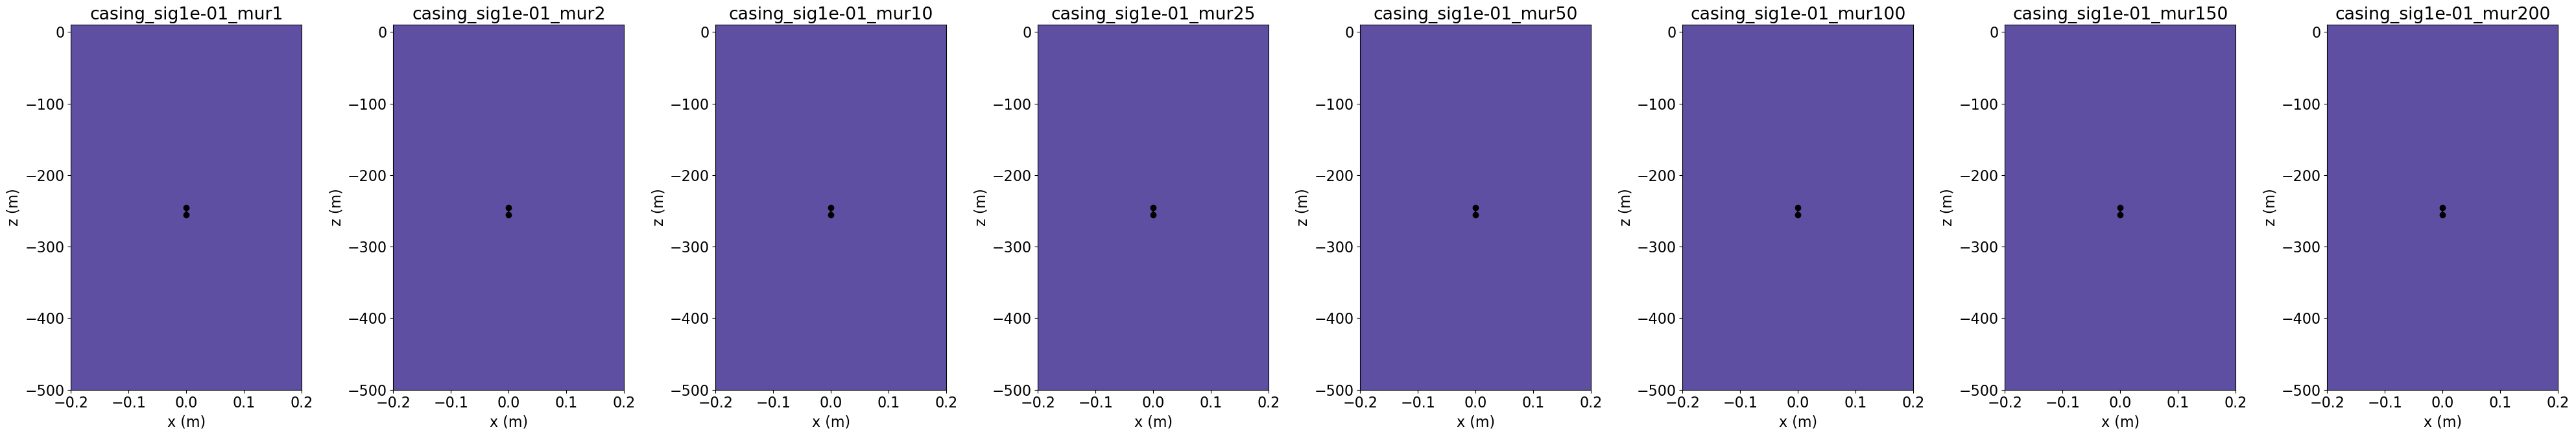

In [185]:
plot_keys = keys
fig, ax = plt.subplots(1, len(plot_keys), figsize=(5*len(plot_keys), 7))

xlim = 0.2*np.r_[-1, 1]
zlim = np.r_[-500, 10]
vmin = sigma_air
vmax = sigma_casing

for i, key in enumerate(plot_keys):
    plot_casing(models[key]["sigma"], xlim=xlim, zlim=zlim, vmin=vmin, vmax=vmax, ax=ax[i])
    ax[i].set_title(key)
    ax[i].plot(np.r_[0, 0], src_z + src_dz/2 * np.r_[-1, 1], "-ok")

plt.tight_layout()
# for loc in src_z:
#     ax.plot(np.r_[0, 0], loc + src_dz/2*np.r_[-1, 1], "-k", lw=4, alpha=0.5)

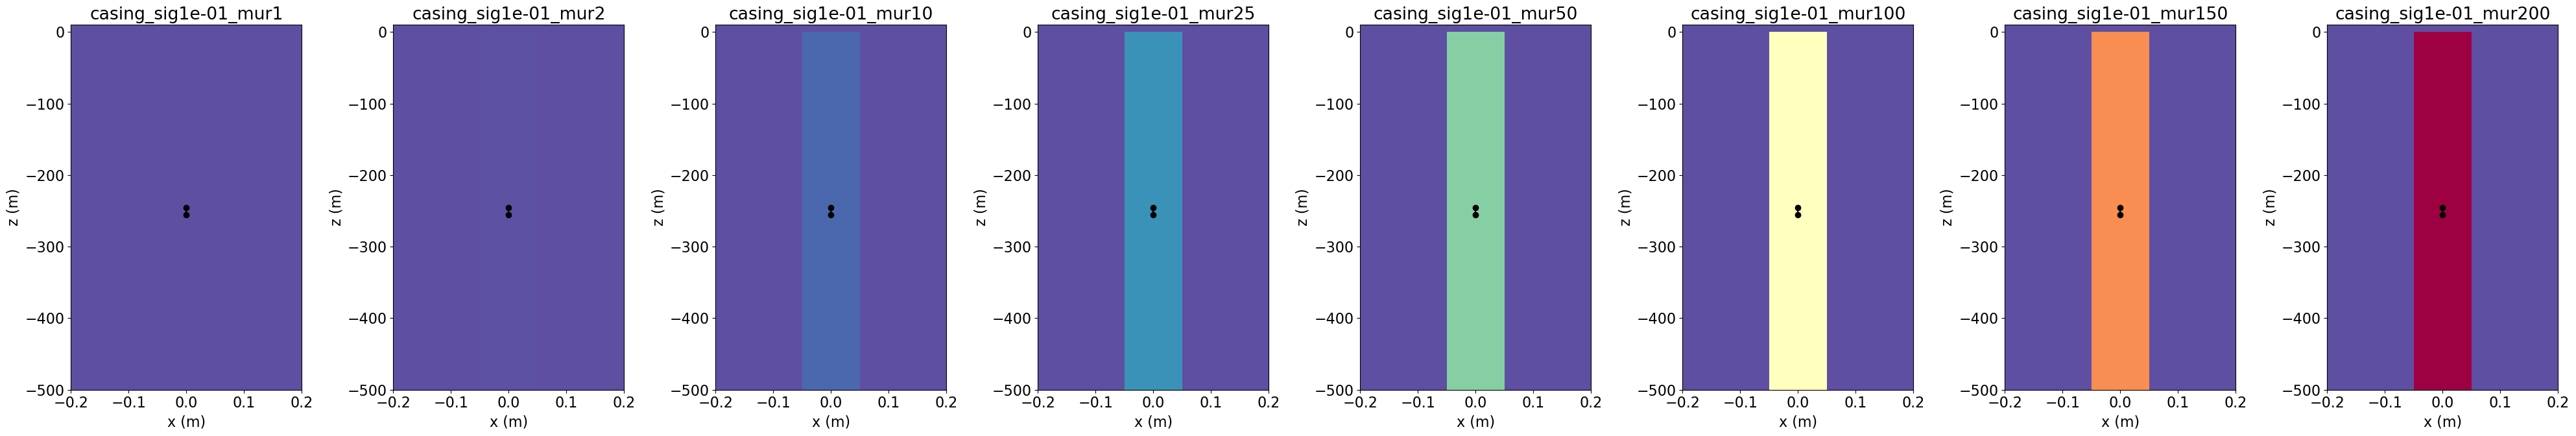

In [186]:
plot_keys = keys
fig, ax = plt.subplots(1, len(plot_keys), figsize=(5*len(plot_keys), 7))

xlim = 0.2*np.r_[-1, 1]
zlim = np.r_[-500, 10]
vmin = 1
vmax = mur_casing.max()

for i, key in enumerate(plot_keys):
    plot_casing(models[key]["mur"], xlim=xlim, zlim=zlim, vmin=vmin, vmax=vmax, ax=ax[i], logscale=False)
    ax[i].set_title(key)
    ax[i].plot(np.r_[0, 0], src_z + src_dz/2 * np.r_[-1, 1], "-ok")

plt.tight_layout()
# for loc in src_z:
#     ax.plot(np.r_[0, 0], loc + src_dz/2*np.r_[-1, 1], "-k", lw=4, alpha=0.5)

## set up the simulations

In [187]:
frequencies = np.r_[1e-4] #10**np.linspace(-1, 4, 36)
frequencies

array([0.0001])

In [188]:
src_list = []
src_locations = np.array([
    [0, 0, src_z+src_dz/2.],
    [0, 0, src_z-src_dz/2.]
])
for f in frequencies: 
    src = fdem.sources.LineCurrent([], location=src_locations, frequency=f)
    src_list.append(src)

wires = maps.Wires(("sigma", mesh.n_cells), ("mur", mesh.n_cells))
permeability_map = maps.MuRelative(mesh)

survey = fdem.Survey(src_list)

sim = fdem.simulation.Simulation3DMagneticField(
    mesh=mesh, sigmaMap=wires.sigma, muMap=permeability_map * wires.mur,
    survey=survey, solver=Pardiso, #mu=mur * mu_0
#     verbose=True
)

In [189]:
def run_simulation(key):
    
    filename = os.path.sep.join([directory_path, key])

    t = time.time()
    print(f"starting {key}..., saving to {filename}")
    fields = sim.fields(np.r_[models[key]["sigma"], models[key]["mur"]])
    print(f" ... done. {time.time()-t:1.2e} \n")
    
    np.save(filename, fields[:, "hSolution"])

    return fields

In [190]:
fields = {}

In [191]:
for key in keys: 
    if key not in fields: 
        fields[key] = run_simulation(key)

starting casing_sig1e-01_mur1..., saving to /t40array/lheagy/casing-upscaling/casing_sig1e-01_mur1
 ... done. 4.44e-01 

starting casing_sig1e-01_mur2..., saving to /t40array/lheagy/casing-upscaling/casing_sig1e-01_mur2
 ... done. 2.53e-01 

starting casing_sig1e-01_mur10..., saving to /t40array/lheagy/casing-upscaling/casing_sig1e-01_mur10
 ... done. 2.27e-01 

starting casing_sig1e-01_mur25..., saving to /t40array/lheagy/casing-upscaling/casing_sig1e-01_mur25
 ... done. 2.21e-01 

starting casing_sig1e-01_mur50..., saving to /t40array/lheagy/casing-upscaling/casing_sig1e-01_mur50
 ... done. 2.18e-01 

starting casing_sig1e-01_mur100..., saving to /t40array/lheagy/casing-upscaling/casing_sig1e-01_mur100
 ... done. 2.15e-01 

starting casing_sig1e-01_mur150..., saving to /t40array/lheagy/casing-upscaling/casing_sig1e-01_mur150
 ... done. 2.15e-01 

starting casing_sig1e-01_mur200..., saving to /t40array/lheagy/casing-upscaling/casing_sig1e-01_mur200
 ... done. 2.27e-01 



In [192]:
fields

{'casing_sig1e-01_mur1': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f8709f261d0>,
 'casing_sig1e-01_mur2': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f870a12eb90>,
 'casing_sig1e-01_mur10': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f86f4228290>,
 'casing_sig1e-01_mur25': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f8709e12290>,
 'casing_sig1e-01_mur50': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f87043cab90>,
 'casing_sig1e-01_mur100': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f87044a4810>,
 'casing_sig1e-01_mur150': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f870a3e7550>,
 'casing_sig1e-01_mur200': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f870a211bd0>}

In [193]:
# def load_fields(name, conductivity, mur):
#     solution = np.load(f"{directory}/fields_{name}.npy")
#     sim = generate_simulation(mur)
#     sim.model = conductivity
#     f = sim.fieldsPair(sim)
#     f[:, sim._solutionType] = solution
#     return f

In [194]:
def plot_fields(
    field_plot, freq_ind=0, xlim=500*np.r_[-1, 1], zlim=np.r_[-1000, 10], component="real", ax=None, vmin=None, vmax=None, aspect=True,
    plot_source=False
):
    if ax is None: 
        fig, ax = plt.subplots(1,1)

    if len(field_plot) == mesh.n_faces: 
        field_plot = mesh.average_face_to_cell_vector * np.squeeze(field_plot)
        
        out = mesh.plot_image(
            getattr(field_plot, component), "CCv", view="vec", 
            range_x = xlim, range_y = zlim,
            sample_grid = np.r_[np.diff(xlim)/100, np.diff(zlim)/100],
            mirror=True, #mirror_data=field_mirror,
            ax=ax, 
            pcolor_opts={"norm":LogNorm(vmin=vmin, vmax=vmax)},
            stream_threshold=vmin
        )

    elif len(field_plot) == mesh.n_edges: 
        field_plot = mesh.average_edge_to_cell_vector * np.squeeze(field_plot)
        
        out = mesh.plot_image(
            getattr(field_plot, component), "CC",  
            range_x = xlim, range_y = zlim,
            mirror=True, mirror_data=-1*field_plot,
            ax=ax, 
            pcolor_opts={
                "norm":SymLogNorm(linthresh=vmin if vmin is not None else 1e-12, vmin=-1*vmax if vmax is not None else None, vmax=vmax),
                "cmap":"RdBu_r",
            },
            stream_threshold=vmin
        )

    if plot_source is True: 
        ax.plot(src_locations[:, 0], src_locations[:, 2], "w", lw=2)
    
    cb = plt.colorbar(out[0], ax=ax)
    # cb.set_label("Electric Field (V/m)")
    if aspect is True:
        ax.set_aspect(1)

    return out, cb

In [195]:
# inds_j_400_z = (
#     mesh.faces_z[:, 2] == mesh.nodes_z[267]
# )

# inds_j_400 = np.hstack(
#     [np.zeros(mesh.n_faces_x, dtype=bool), inds_j_400_z]
# )

In [196]:
# colors = plt.cm.viridis(np.linspace(0, 1, len(frequencies)))

In [197]:
# fig, ax = plt.subplots(2, 1, sharex=True)

# key = keys[0]
# key

# freq_inds = [0, 7, 14, 21, 28]

# for i, freq in enumerate(frequencies): 
#     fields_plot = fields[key]
#     src = fields_plot.survey.source_list[i]
#     j_plt = fields[key][src, "j"][inds_j_400]
#     ax[0].plot(mesh.cell_centers_x, j_plt.real, color=colors[i])
#     ax[1].plot(mesh.cell_centers_x, j_plt.imag, color=colors[i])

#     # ax[1, 0].semilogy(mesh.cell_centers_x, np.abs(j_plt.real), color=colors[i])
#     # ax[1, 1].semilogy(mesh.cell_centers_x, np.abs(j_plt.imag), color=colors[i])

# ax[0].set_xlim([0, 0.1])

# for a in ax.flatten():
#     a.set_ylim([-6, 12])
#     a.grid()

# # for a in ax[1, :].flatten():
# #     a.set_ylim([1e-2, 1e2])



In [198]:
src_locations

array([[   0.,    0., -245.],
       [   0.,    0., -255.]])

In [199]:
# dc response 

dc_src_list = [
    dc.sources.Dipole([], location_a=src_locations[0,:], location_b=src_locations[-1,:])
]
dc_survey = dc.Survey(dc_src_list)
dc_sim = dc.simulation.Simulation3DCellCentered(
    mesh=mesh, sigmaMap=maps.IdentityMap(mesh),
    survey=dc_survey, solver=Pardiso, bc_type="Dirichlet",
#     verbose=True
)

In [200]:
hollow_wells = {}
# solid_wells = {}

for i, key in enumerate(keys): 
    
    hollow_well = get_physical_property_model(
        mesh, casing_a, casing_b, casing_l, sigma_back=sigma_back, sigma_casing=sigma_casing, sigma_air=sigma_air, mur_casing=mur_casing[i]
    )
    hollow_wells[key] = {
        "sigma": hollow_well[0],
        "mur": hollow_well[1]
    }
    

In [201]:
dc_fields_hollow = dc_sim.fields(models[keys[0]]["sigma"])
# dc_fields_solid = dc_sim.fields(solid_wells[keys[0]]["sigma"])

In [202]:
def getAmmr(mur):
    vol = mesh.cell_volumes
    Div = discretize.utils.sdiag(vol) * mesh.face_divergence
    MeMuI = mesh.get_edge_inner_product(mur * mu_0, invert_matrix=True)
    mui = 1./(mur*mu_0)
    return (
        mesh.edge_curl
        * MeMuI
        * mesh.edge_curl.T.tocsr()
        - Div.T.tocsr()
        * discretize.utils.sdiag(1.0 / vol * mui)
        * Div  # stabalizing term. See (Chen, Haber & Oldenburg 2002)
    )

In [203]:
dc_src = dc_src_list[0]

In [204]:
js_dc = line_through_faces(
    mesh, dc_src.location, normalize_by_area=True
)

In [205]:
def solve_mmr(mur, dc_fields):
    Ammr = getAmmr(mur)
    Ammr_inv = Pardiso(Ammr)
    rhs = js_dc + dc_fields[:, "j"].flatten()
    mmr_a = Ammr_inv * rhs
    
    MeMuI = mesh.get_edge_inner_product(mur * mu_0, invert_matrix=True)
    b_mmr = mesh.edge_curl.T * mmr_a
    h_mmr = MeMuI * b_mmr

    return {
        "a": mmr_a, 
        "b": b_mmr, 
        "h": h_mmr
    }


    

In [206]:
mmr_hollow = {}

for key in keys:
    mmr_hollow[key] = solve_mmr(hollow_wells[key]["mur"], dc_fields_hollow)
    

In [207]:
plot_inds = mesh.edges[:, 0] == mesh.nodes_x[np.argmin(np.abs(mesh.nodes_x - casing_b)) - 1]

In [208]:
# fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# xlim = np.r_[0, -casing_l]

# solution = mmr_hollow

# ax[0].plot(mesh.nodes_z, solution[keys[0]]["b"][plot_inds], color="k")

# for i, key in enumerate(keys[1:]):
#     ax[0].plot(mesh.nodes_z, solution[key]["b"][plot_inds], label=f"{key.split('_')[2][3:]} $\mu_0$", color=f"C{i}")
#     # ax[0].plot(mesh.nodes_z, mur_casing[i+1]*b_mmr[keys[0]][plot_inds], label=f"{key.split('_')[2][3:]} $\mu_0$", color=f"C{i}", ls="--")
#     ax[1].plot(mesh.nodes_z, ((solution[key]["b"]-solution[keys[0]]["b"])/solution[keys[0]]["b"])[plot_inds], label=key)

# ax[0].legend()
# for a in ax:
#     a.set_xlim(xlim)
#     a.grid()
# # ax[0].set_ylim(-1e-8, 3e-8)
# plt.tight_layout()

In [209]:
for i, key in enumerate(keys[1:]):  
    hollow_sol = ((mmr_hollow[key]["b"]-mmr_hollow[keys[0]]["b"])/mmr_hollow[keys[0]]["b"])[plot_inds]
    # solid_sol = ((mmr_solid[key]["b"]-mmr_solid[keys[0]]["b"])/mmr_solid[keys[0]]["b"])[plot_inds]
    # print(f"{key:25s}: {hollow_sol.max():6.2f}, {solid_sol.max():6.2f}, {hollow_sol.max()/solid_sol.max():6.2f}")

In [210]:
for i, key in enumerate(keys[1:]):  
    hollow_sol = (mmr_hollow[key]["b"])[plot_inds]
    # solid_sol = (mmr_solid[key]["b"])[plot_inds]
    # print(f"{key:25s}: {hollow_sol.max():1.2e}, {solid_sol.max():1.2e}, {hollow_sol.max()/solid_sol.max():6.2f}")

In [211]:
def plot_fields_line(field_type, zloc=-10, xlim=np.r_[0, 0.2], ax=None):
    freq_ind=0
    if ax is None: 
        fig, ax = plt.subplots(3, 2, figsize=(12, 12), sharex=True)
    
    if field_type in ["h", "b"]:
        plot_inds = mesh.edges[:, 2] == mesh.nodes_z[np.argmin(np.abs(mesh.nodes_z - zloc))]
        x = mesh.nodes_x
        dc_soln = np.squeeze(mmr_hollow[keys[0]][field_type][plot_inds])
        
    elif field_type in ["ex", "jx"]: 
        plot_inds_ex = mesh.faces_x[:, 2] == mesh.cell_centers_z[np.argmin(np.abs(mesh.nodes_z - zloc))]
        plot_inds = np.hstack([plot_inds_ex, np.zeros(mesh.n_faces_z, dtype=bool)]) 
        x = mesh.nodes_x
        dc_soln = np.squeeze(dc_fields_hollow[:, field_type[0]][plot_inds])
        
    elif field_type in ["ez", "jz"]:
        plot_inds_ez = mesh.faces_z[:, 2] == mesh.nodes_z[np.argmin(np.abs(mesh.nodes_z - zloc))]
        plot_inds = np.hstack([np.zeros(mesh.n_faces_x, dtype=bool), plot_inds_ez])
        x = mesh.cell_centers_x
        dc_soln = np.squeeze(dc_fields_hollow[:, field_type[0]][plot_inds])

    ax[0, 0].plot(x, dc_soln, color="k", label="DC")

    for i, key in enumerate(fields.keys()):
        val = fields[key]
        src = val.simulation.survey.source_list[freq_ind]
        legend = f"{key.split('_')[-1][3:]} $\mu_0$"
        ax[0, 0].plot(x, val[src, field_type[0]][plot_inds].real, label=legend)
        ax[0, 1].plot(x, val[src, field_type[0]][plot_inds].imag, label=legend)
    
        inductive_real = np.squeeze(val[src, field_type[0]][plot_inds].real) - dc_soln
        ax[1, 0].plot(x, inductive_real, label=legend)
        ax[1, 1].plot(x, val[src, field_type[0]][plot_inds].imag, label=legend)
    
        if i <= 0: 
            inductive_real_mu0 = inductive_real
            inductive_imag_mu0 = val[src, field_type[0]][plot_inds].imag
        elif i > 0:
            ax[2, 0].plot(x, inductive_real / (inductive_real_mu0), color=f"C{i}")
            ax[2, 1].plot(x, val[src, field_type[0]][plot_inds].imag / (inductive_imag_mu0), color=f"C{i}")  

    ax[0, 0].legend()
    ax[0, 0].set_xlim(xlim)

    ax[0, 0].set_title(f"{field_type} real")
    ax[0, 1].set_title(f"{field_type} imag")
    
    ax[1, 0].set_title(f"{field_type} real - {field_type} dc")
    ax[1, 1].set_title(f"{field_type} imag")
    
    ax[2, 0].set_title(f"({field_type} real - {field_type} dc) / ({field_type}(mu_0) real - {field_type} dc)")
    ax[2, 1].set_title(f"{field_type} imag / {field_type}(mu_0) imag ")
    
    for a in ax.flatten():
        a.grid()
        
    return ax

In [212]:
casing_a, casing_b

(0.0, 0.05)

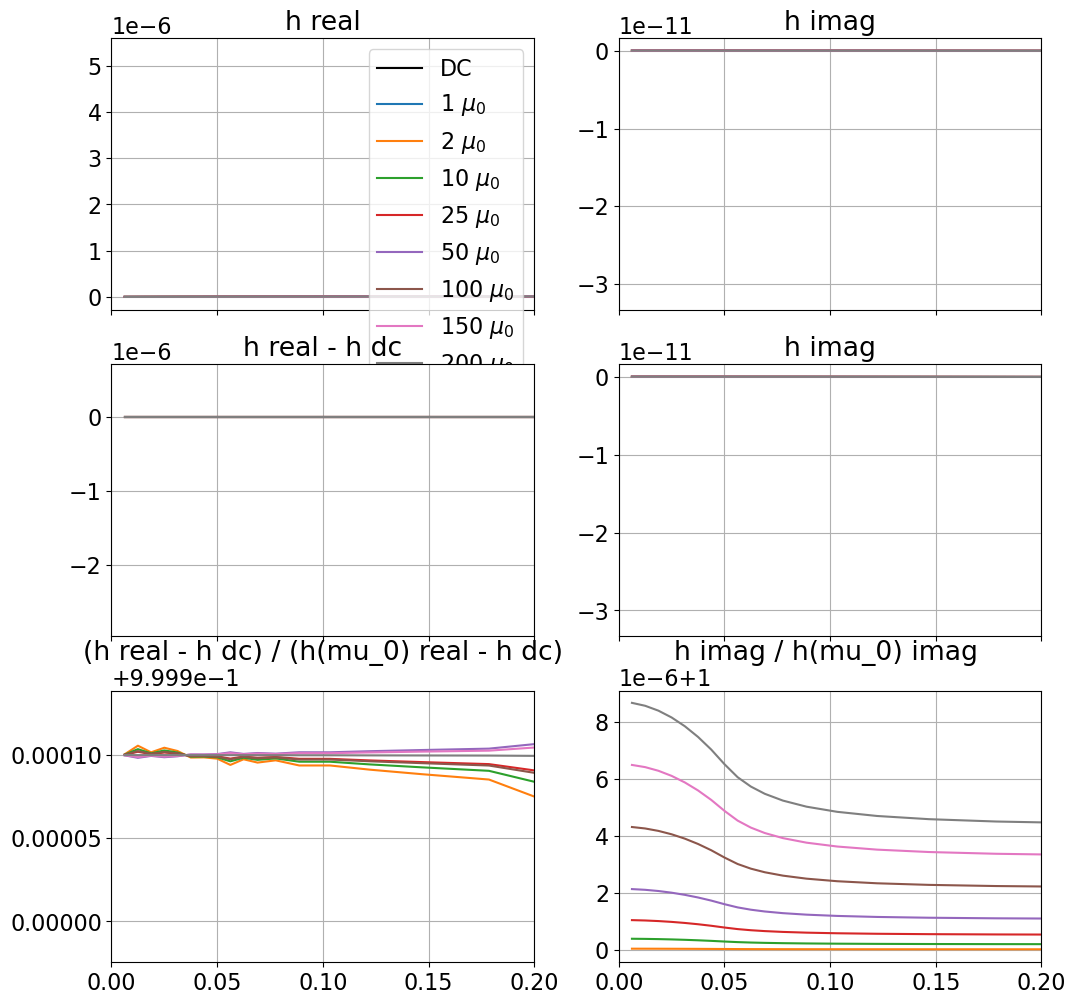

In [213]:
ax = plot_fields_line("h")

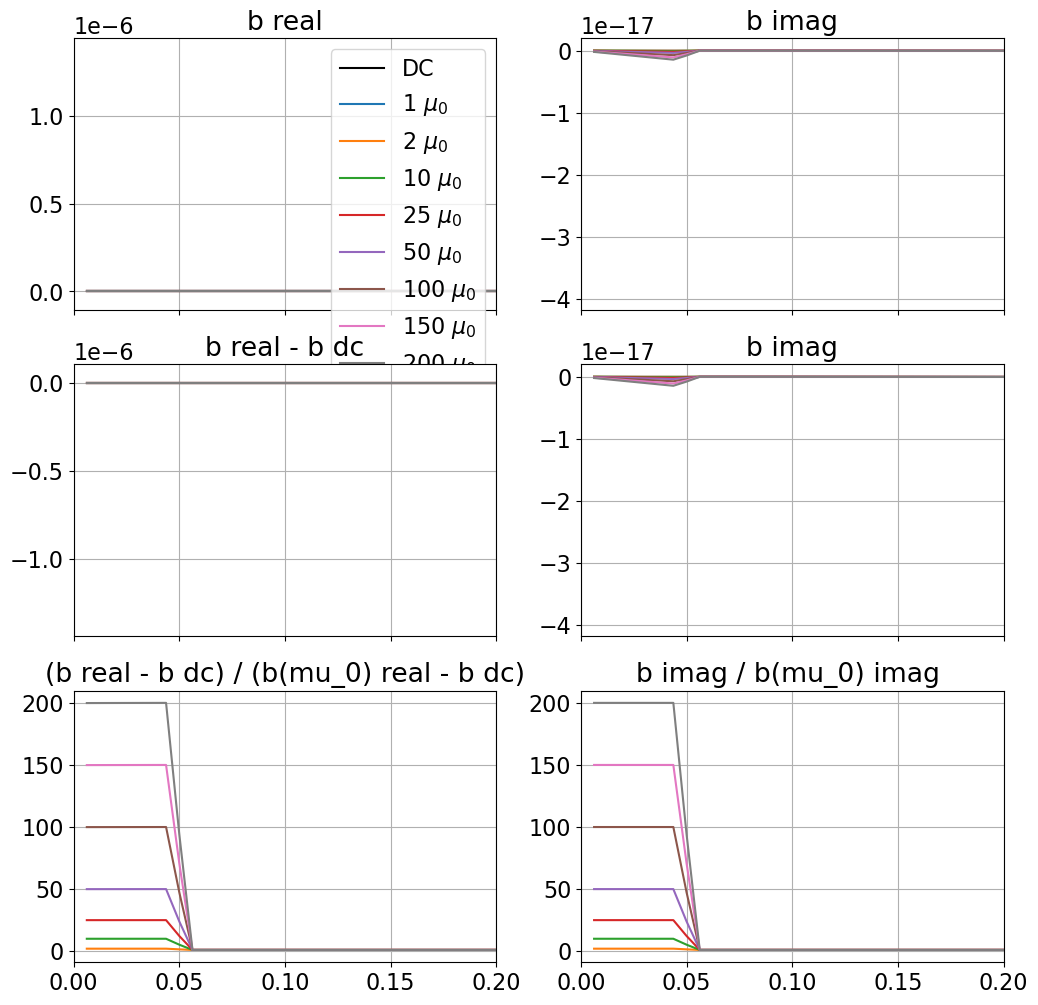

In [214]:
ax = plot_fields_line("b")

In [215]:
# ax = plot_fields_line("ex")
# # ax[2, 1].set_ylim([-1, 4])

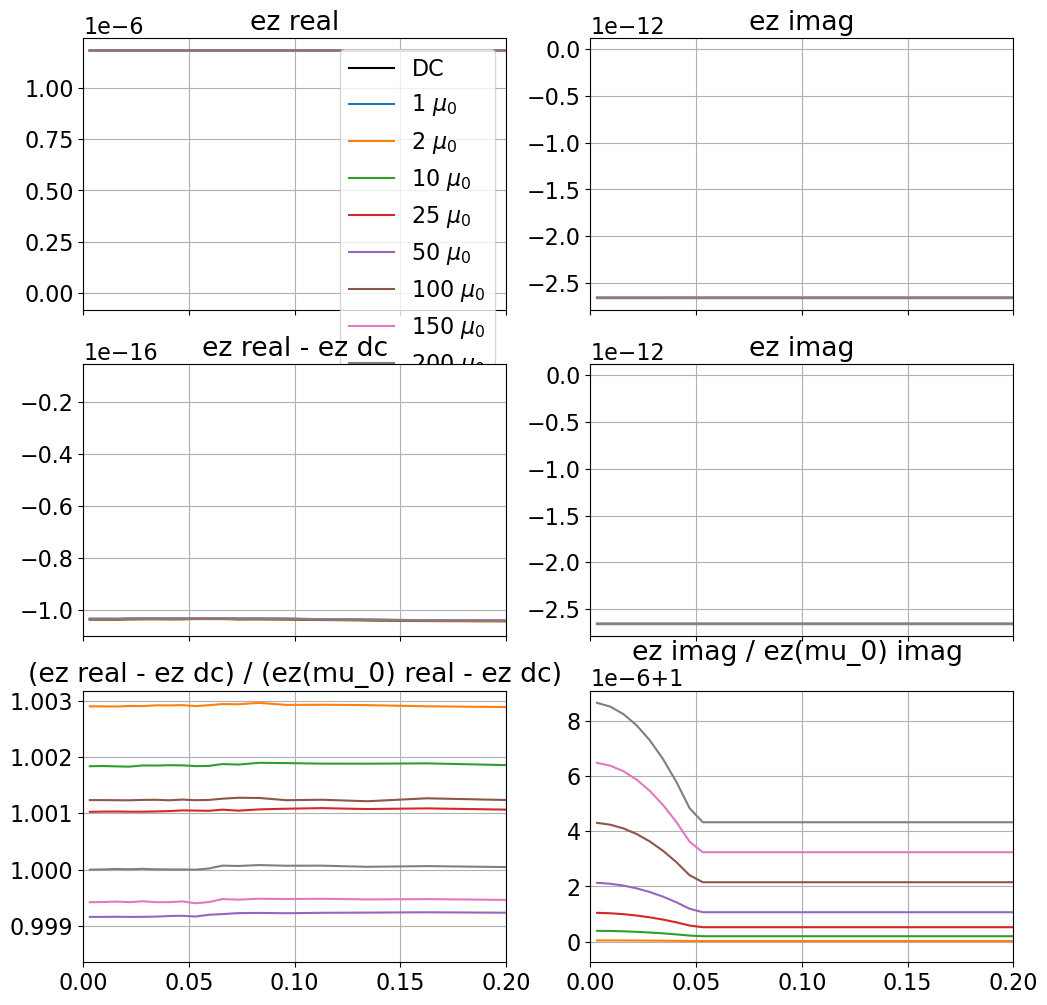

In [216]:
ax = plot_fields_line("ez")
# ax[2, 1].set_ylim(0.9, 1.1)

In [217]:
# ax = plot_fields_line("jx")
# # ax[2, 1].set_ylim([0, 4])

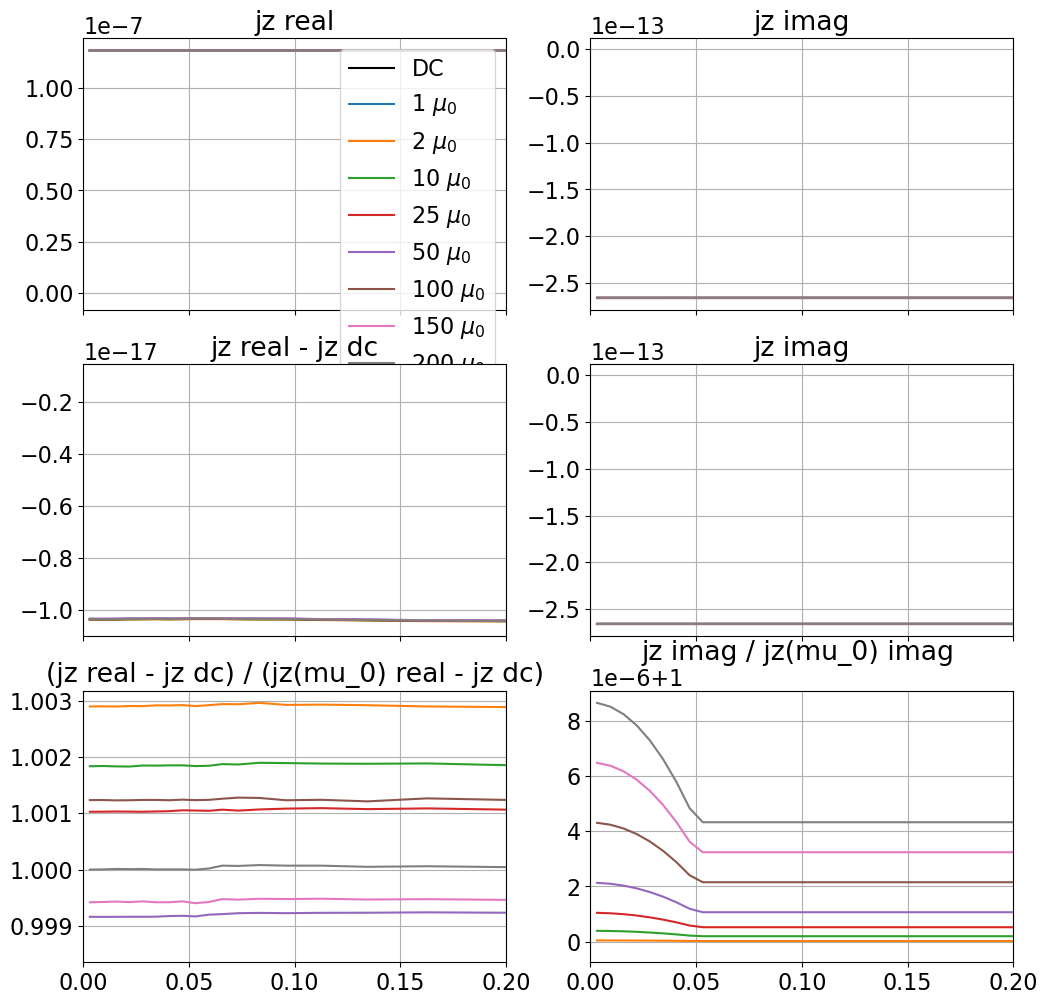

In [218]:
ax = plot_fields_line("jz")
# ax[2, 1].set_ylim([0.9, 1.1])

# plot the integral of Phi b as a function of mu, e imag as a function of mu

In [146]:
radial_inds_casing = (mesh.cell_centers_x <= casing_b) & (mesh.cell_centers_x >= casing_a)
mesh.cell_centers_x[radial_inds_casing]

array([0.040625, 0.041875, 0.043125, 0.044375, 0.045625, 0.046875,
       0.048125, 0.049375])

In [161]:
zloc = -250
plot_inds_h = mesh.edges[:, 2] == mesh.nodes_z[np.argmin(np.abs(mesh.nodes_z - zloc))]

In [162]:
b_casing_integral = np.zeros_like(mur_casing, dtype=complex)

for i, val in enumerate(fields.values()):
    b_line = val[:, "b"][plot_inds_h] 
    b_line_area = (b_line[1:] + b_line[:-1]) / 2 * mesh.h[0].min() * mesh.cell_centers_x * 2 * np.pi
    b_line_in_casing = b_line_area[radial_inds_casing[:-1]]
    b_casing_integral[i] = np.sum(b_line_in_casing)

In [163]:
z_loc = -250
x_loc = 0.1
plot_ind_ez = (
    (mesh.faces_z[:, 2] == mesh.nodes_z[np.argmin(np.abs(mesh.nodes_z - z_loc))]) & 
    (mesh.faces_z[:, 0] == mesh.cell_centers_x[np.argmin(np.abs(mesh.cell_centers_x - x_loc))])
)
plot_ind_ez_all = np.hstack([ np.zeros(mesh.n_faces_x, dtype=bool), plot_ind_ez])

mesh.faces_z[plot_ind_ez, :]

array([[ 1.03539968e-01,  0.00000000e+00, -2.50000000e+02]])

In [169]:
e_at_location = np.zeros_like(mur_casing, dtype=complex)

for i, val in enumerate(fields.values()): 
    e_at_location[i] = val[:, "e"][plot_ind_ez_all] / fields[keys[0]][:, "e"][plot_ind_ez_all]

In [170]:
mur_casing

array([  1,   2,  10,  25,  50, 100, 150, 200])

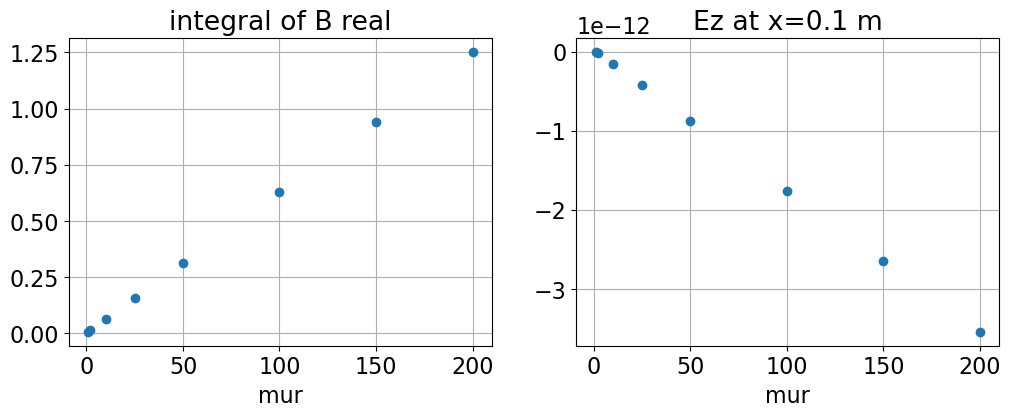

In [171]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(mur_casing, b_casing_integral.real, "o")
ax[1].plot(mur_casing, e_at_location.imag, "o") 

ax[0].set_xlabel("mur")
ax[0].set_title("integral of B real")

ax[1].set_xlabel("mur")
ax[1].set_title(f"Ez at x={x_loc} m")

for a in ax.flatten():
    a.grid()

In [172]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(np.atleast_2d(b_casing_integral.real).T, -e_at_location.imag)

In [173]:
reg.coef_, reg.intercept_

(array([2.84267892e-12]), -2.0096026955779108e-14)

Text(0, 0.5, 'Ez imag at r=0.1m')

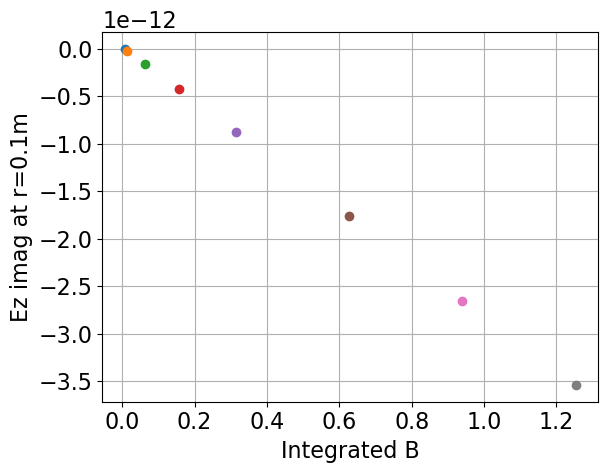

In [174]:
fig, ax = plt.subplots(1, 1)

for i in range(len(mur_casing)): 
    ax.plot(b_casing_integral[i].real, e_at_location[i].imag, "o")
ax.grid()

ax.set_xlabel("Integrated B")
ax.set_ylabel(f"Ez imag at r={x_loc}m")

In [132]:
e_at_location.imag

array([-2.65460048e-12, -2.65460050e-12, -2.65460067e-12, -2.65460099e-12,
       -2.65460151e-12, -2.65460256e-12, -2.65460360e-12, -2.65460465e-12])

In [133]:
# fig, ax = plt.subplots(1, 1)

# for i in range(len(mur_casing)): 
#     ax.plot(b_casing_integral[i].real/b_casing_integral[0].real, e_at_location[i].imag/e_at_location[0].imag, "o")
# ax.grid()

# # ax.set_xlabel("Integrated B")
# # ax.set_ylabel(f"Er imag at r={x_loc}m")

In [153]:
z_loc = -300
x_loc = 0.1
plot_ind_ex = (
    (mesh.faces_x[:, 2] == mesh.cell_centers_z[np.argmin(np.abs(mesh.cell_centers_z - z_loc))]) & 
    (mesh.faces_x[:, 0] == mesh.nodes_x[np.argmin(np.abs(mesh.nodes_x - x_loc))])
)
plot_ind_ex_all = np.hstack([plot_ind_ex, np.zeros(mesh.n_faces_z, dtype=bool)])

mesh.faces_x[plot_ind_ex, :]

array([[ 9.62879149e-02,  0.00000000e+00, -3.00250000e+02]])

In [154]:
ex_at_location = np.zeros_like(mur_casing, dtype=complex)

for i, val in enumerate(fields.values()): 
    ex_at_location[i] = val[:, "e"][plot_ind_ex_all]

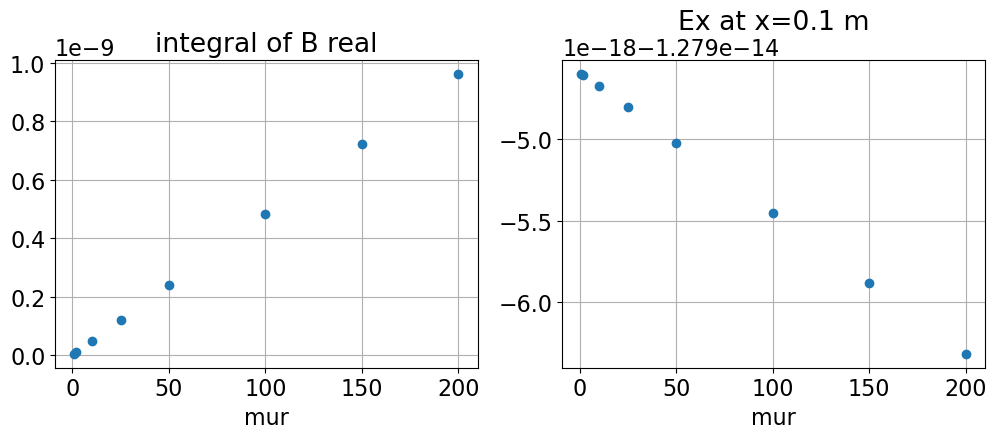

In [155]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(mur_casing, b_casing_integral.real, "o")
ax[1].plot(mur_casing, -ex_at_location.imag, "o") 

ax[0].set_xlabel("mur")
ax[0].set_title("integral of B real")

ax[1].set_xlabel("mur")
ax[1].set_title(f"Ex at x={x_loc} m")

for a in ax.flatten():
    a.grid()

Text(0, 0.5, 'Er imag at r=0.1m')

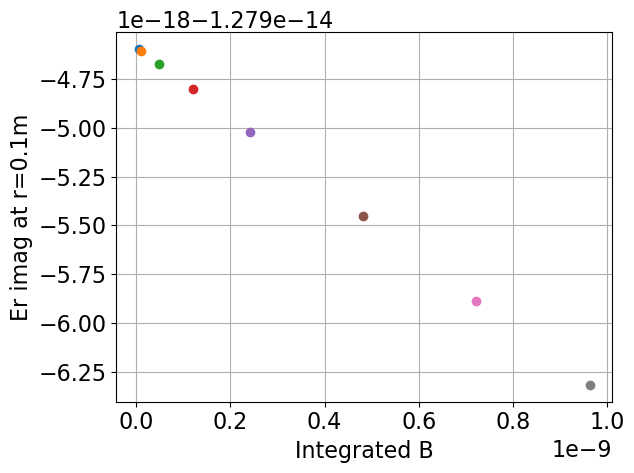

In [156]:
fig, ax = plt.subplots(1, 1)

for i in range(len(mur_casing)): 
    ax.plot(b_casing_integral[i].real, -ex_at_location[i].imag, "o")
ax.grid()

ax.set_xlabel("Integrated B")
ax.set_ylabel(f"Er imag at r={x_loc}m")

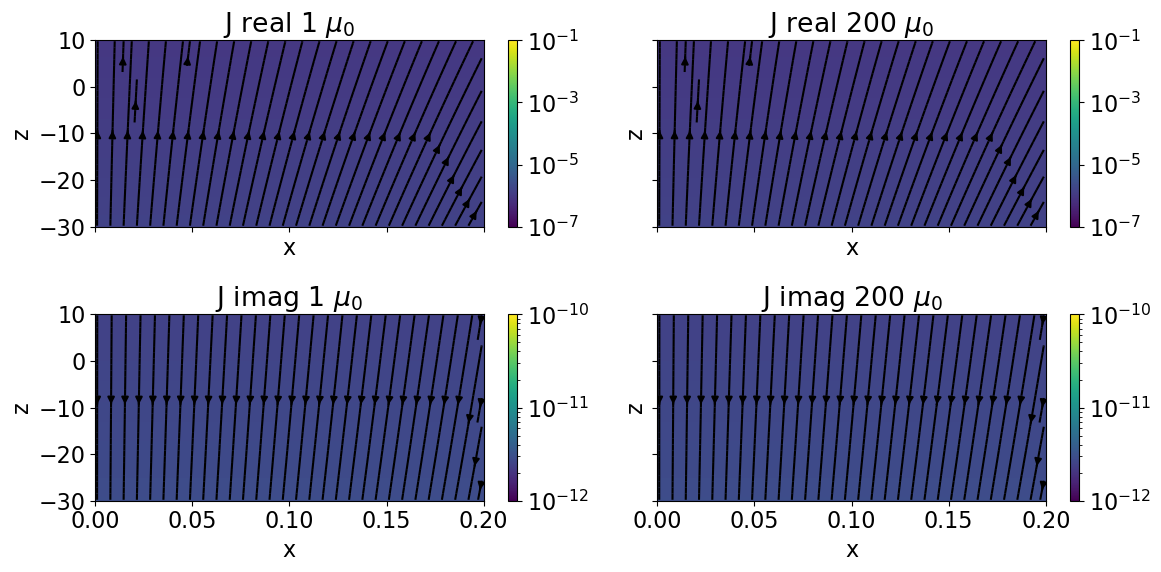

In [157]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True)

xlim=np.r_[0, 0.2]
zlim=np.r_[-30, 10]

vminreal = 1e-7
vmaxreal = 1e-1

vminimag = 1e-12
vmaximag = 1e-10

for i, key in enumerate([keys[0], keys[-1]]): 

    legend = f"{key.split('_')[-1][3:]} $\mu_0$"
    
    ax[0, i].set_title(f"J real {legend}")
    ax[1, i].set_title(f"J imag {legend}")
    
    plot_fields(
        fields[key][:, "e"], component="real", ax=ax[0, i], xlim=xlim, zlim=zlim, aspect=False, vmin=vminreal, vmax=vmaxreal, 
    )
    plot_fields(
        fields[key][:, "e"], component="imag", ax=ax[1, i], xlim=xlim, zlim=zlim, aspect=False, vmin=vminimag, vmax=vmaximag, 
    )

plt.tight_layout()

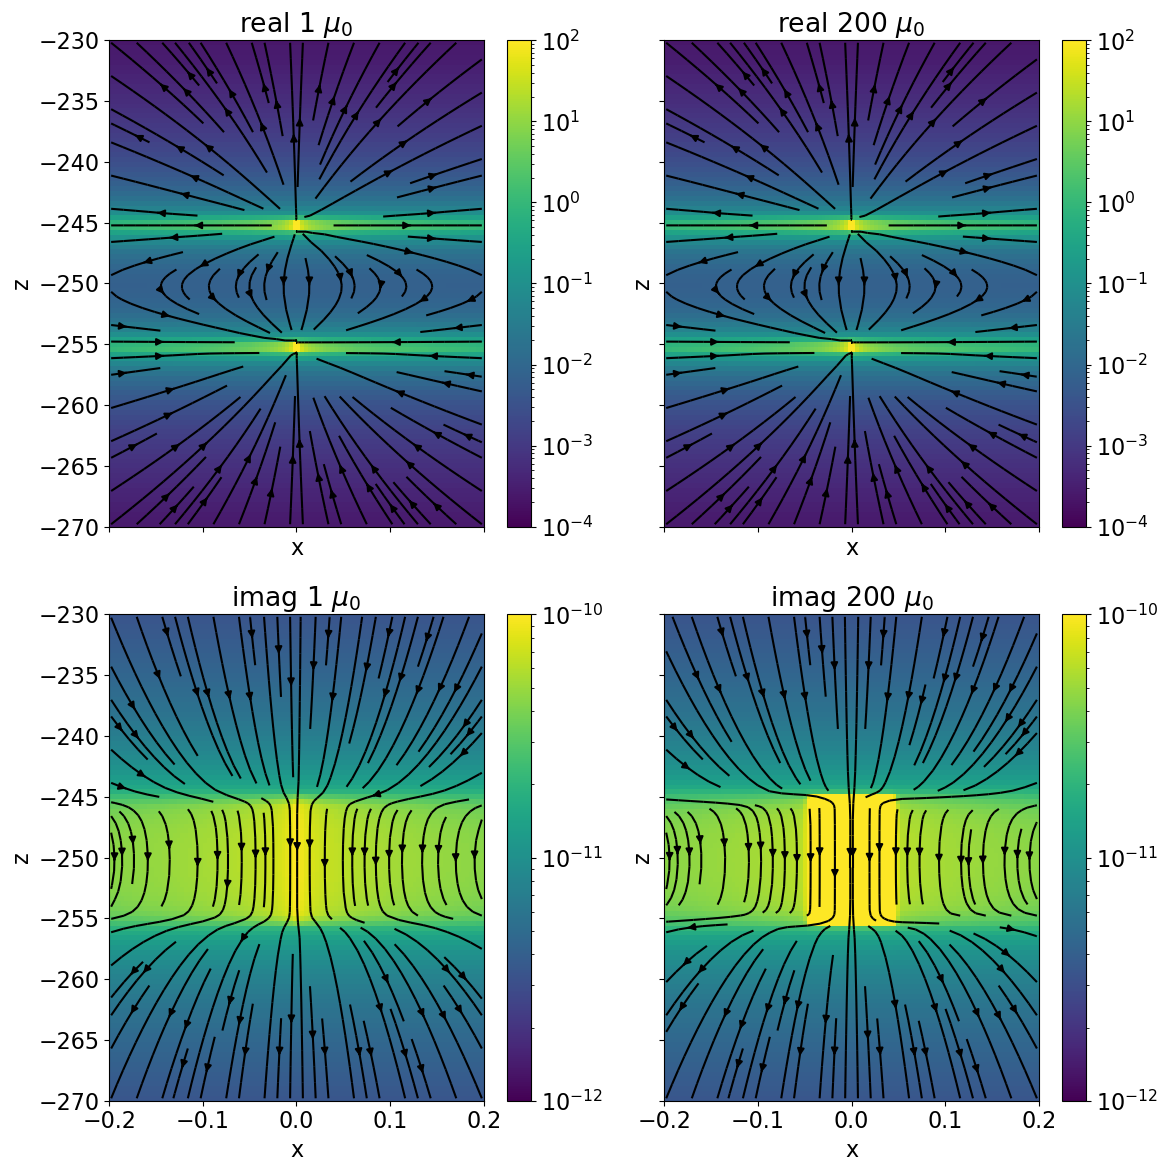

In [160]:
fig, ax = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)

xlim=0.2 * np.r_[-1, 1]
zlim=np.r_[-270, -230]

vminreal = 1e-4
vmaxreal = 1e2

vminimag = 1e-12
vmaximag = 1e-10

for i, key in enumerate([keys[0], keys[-1]]): 

    legend = f"{key.split('_')[-1][3:]} $\mu_0$"
    
    ax[0, i].set_title(f"real {legend}")
    ax[1, i].set_title(f"imag {legend}")
    
    plot_fields(
        fields[key][:, "j"], component="real", ax=ax[0, i], xlim=xlim, zlim=zlim, aspect=False, vmin=vminreal, vmax=vmaxreal, 
    )
    plot_fields(
        fields[key][:, "j"], component="imag", ax=ax[1, i], xlim=xlim, zlim=zlim, aspect=False, vmin=vminimag, vmax=vmaximag, 
    )

plt.tight_layout()